In [2]:
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
import numpy as np
import pandas as pd

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [3]:
iris = load_iris()

X = iris.data
y = iris.target

print("Features Shape:", X.shape)
print("Labels Shape:", y.shape)

Features Shape: (150, 4)
Labels Shape: (150,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (120, 4)
Testing Data: (30, 4)


In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train[:5])

[[-1.47393679  1.20365799 -1.56253475 -1.31260282]
 [-0.13307079  2.99237573 -1.27600637 -1.04563275]
 [ 1.08589829  0.08570939  0.38585821  0.28921757]
 [-1.23014297  0.75647855 -1.2187007  -1.31260282]
 [-1.7177306   0.30929911 -1.39061772 -1.31260282]]


In [6]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print(y_train[:5])

[[1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [8]:
model = keras.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(4,)),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(3, activation='softmax')
])

print("Model Created Successfully")

Model Created Successfully


In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 204ms/step - accuracy: 0.3229 - loss: 1.0104 - val_accuracy: 0.5000 - val_loss: 0.8430
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.3542 - loss: 0.9871 - val_accuracy: 0.5000 - val_loss: 0.8255
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3854 - loss: 0.9646 - val_accuracy: 0.5417 - val_loss: 0.8093
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.3854 - loss: 0.9440 - val_accuracy: 0.5833 - val_loss: 0.7934
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4271 - loss: 0.9231 - val_accuracy: 0.5833 - val_loss: 0.7783
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4583 - loss: 0.9040 - val_accuracy: 0.7083 - val_loss: 0.7633
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4896 - loss: 0.8858 - val_accuracy: 0.7083 - val_loss: 0.7485
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5521 - loss: 0.8658 - val_accuracy: 0.7083 - val_loss: 0.7345

In [12]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9333 - loss: 0.3185
Test Accuracy: 0.9333333373069763


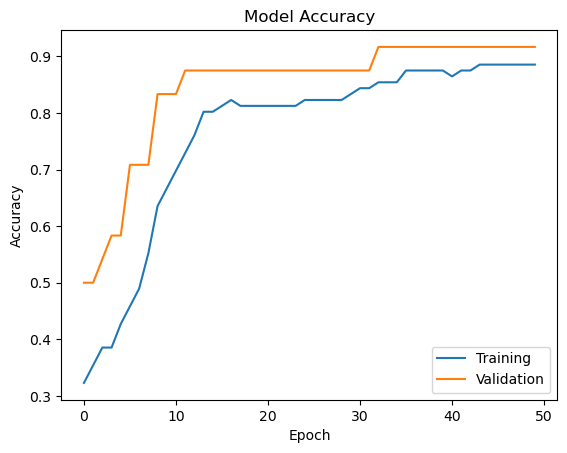

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training", "Validation"])

plt.show()

In [17]:
model.save("iris_model.keras")
print("Model Saved Successfully!")

Model Saved Successfully!
